In [1]:
libraries = c("dplyr", "tidyverse", "magrittr", "ggplot2", "RColorBrewer")
for(x in libraries) {library(x,character.only = TRUE, warn.conflicts = FALSE, quietly = TRUE)}
theme_set(theme_bw())

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.1.5
✔ ggplot2   4.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.2.0     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Settings for age groups

In [2]:
#### age group
group_num <- 10
age_limit <- 100
age <- 1:age_limit
group <- (age - 1) %/% 10 + 1
n_sus = 10000

## Settings for the target population-level FoI and IFR

In [3]:
## target values for FoI and IFR (in %)
target_foi <- c(0.1, 1, 3)
target_IFR <- c(0.5, 1, 3, 5)

## Age group-specific profile of IFR

In [4]:
IFR_class <- c("Decreasing IFR", "U-shaped IFR", "Increasing IFR")

## Decreasing IFR (Measles-like)
ifr_profile_dec = c(.15, .1, .05, .01, .005, .0003, .0003, .0001, .0001, .0001)

## U-shaped IFR (Chikungunya-like; Pérez-Estigarribia et al., Nat Med, 2025)
ifr_profile_u = c(.1, .0005, .0007, .0003, .0002, .004, .014, .1, .1, .1)

## Increasing IFR (SFTS-like)
ifr_profile_inc = c(.0001, .0001, .0003, .005, .01, .05, .1, .15, .15, .15)

ifr_profile_list <- list(ifr_profile_dec, ifr_profile_u, ifr_profile_inc)

## Scaling IFR with age-standardization

In [5]:
## WHO standard population 2000-2025: Ahmad et al., WHO 2001
WHO_standard_pop <- c(.1755, .1707, .1615, .1476, .1263, .0992, .0668, .0373, .0135, .00195)
WHO_standard_pop <- WHO_standard_pop / sum(WHO_standard_pop)

## scaling the IFR profile to make the targeted IFR value
ifr_means <- vapply(ifr_profile_list,function(x) sum(x * WHO_standard_pop), numeric(1))

ifr_profile_scale_list <- lapply(seq_along(ifr_profile_list), function(g) {
    lapply(seq_along(target_IFR), function(k) {ifr_profile_list[[g]] * (target_IFR[k] * .01 / ifr_means[g])})})

In [6]:
## plotting age-group–specific IFR profiles when age-standardized mean is set to 1%
k <- 2; selected_IFR_text <- paste0(target_IFR[k], "%")        
df_list <- list(data.frame(AgeGroup = factor(seq_along(ifr_profile_scale_list[[1]][[k]])),
                           IFR = ifr_profile_scale_list[[1]][[k]], Pattern  = "Decreasing"),
                data.frame(AgeGroup = factor(seq_along(ifr_profile_scale_list[[2]][[k]])),
                           IFR = ifr_profile_scale_list[[2]][[k]], Pattern = "U-shaped"),
                data.frame(AgeGroup = factor(seq_along(ifr_profile_scale_list[[3]][[k]])),
                           IFR = ifr_profile_scale_list[[3]][[k]], Pattern = "Increasing"))

df_all <- bind_rows(df_list) %>% mutate(AgeGroup = as.numeric(AgeGroup)) %>% filter(AgeGroup <= 8) %>% 
mutate(Pattern = factor(Pattern, levels = c("Decreasing", "U-shaped", "Increasing")),
       age_group_fact = if_else(AgeGroup * 10 < 80, as.character((AgeGroup - 1) * 10), "70+"),
       age_group_fact = factor(age_group_fact, levels = c("0", "10", "20", "30", "40", "50", "60", "70+")))

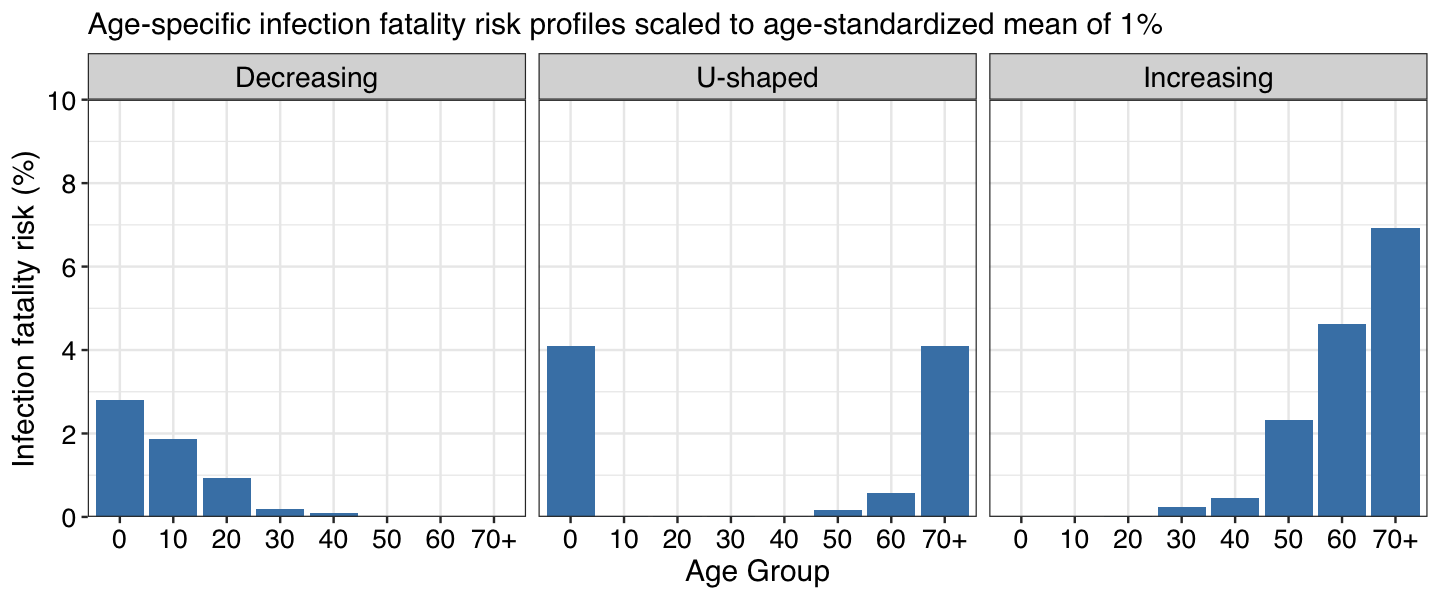

In [7]:
options(repr.plot.width = 12, repr.plot.height = 5)

ggplot(df_all, aes(x = age_group_fact, y = IFR * 100)) +
geom_bar(stat = "identity", fill = "steelblue") +
facet_wrap(~Pattern, nrow = 1) +
labs(x = "Age Group", y = "Infection fatality risk (%)") +
scale_y_continuous(expand = c(0, 0), breaks = c(0, 2, 4, 6, 8, 10), limits = c(0, 10)) +
ggtitle(paste0("Age-specific infection fatality risk profiles scaled to age-standardized mean of ", selected_IFR_text)) +
theme_bw(base_size = 15) +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 16, family = "sans", color = "black"),
      plot.title = element_text(size = 18, family = "sans", color = "black"), 
      strip.text = element_text(size = 17, family = "sans", color = "black"))

ggsave("figures/WHO_age_profile_IFR.png", width = 12, height = 5, dpi = 300, bg = 'white')

In [8]:
## plotting age-group–specific IFR profiles with different target mean IFR
k_seq <- seq(target_IFR)
k_labels <- paste0(target_IFR[k_seq], "%")

bar_order <- c(paste0(target_IFR[4], "%"), paste0(target_IFR[3], "%"), paste0(target_IFR[2], "%"), paste0(target_IFR[1], "%"))

list(do.call(rbind, lapply(k_seq, function(k){
        data.frame(AgeGroup = seq_along(ifr_profile_scale_list[[1]][[k]]), IFR = ifr_profile_scale_list[[1]][[k]],
                   Pattern = "Decreasing", k = k, k_label = k_labels[match(k, k_seq)])})),
                
     do.call(rbind, lapply(k_seq, function(k){
         data.frame(AgeGroup = seq_along(ifr_profile_scale_list[[2]][[k]]), IFR = ifr_profile_scale_list[[2]][[k]],
                    Pattern = "U-shaped", k = k, k_label = k_labels[match(k, k_seq)])})),
     
     do.call(rbind, lapply(k_seq, function(k){
         data.frame(AgeGroup = seq_along(ifr_profile_scale_list[[3]][[k]]), IFR = ifr_profile_scale_list[[3]][[k]],
                    Pattern = "Increasing", k = k, k_label = k_labels[match(k, k_seq)])}))) -> df_list 

df_all <- dplyr::bind_rows(df_list) %>% mutate(AgeGroup = as.numeric(AgeGroup)) %>% filter(AgeGroup <= 8) %>%
mutate(Pattern = factor(Pattern, levels = c("Decreasing", "U-shaped", "Increasing")),
       age_group_fact = dplyr::if_else(AgeGroup * 10 < 80, as.character((AgeGroup - 1) * 10), "70+"),
       age_group_fact = factor(age_group_fact, levels = c("0", "10", "20", "30", "40", "50", "60", "70+")),
       k_label = factor(k_label, levels = k_labels), k_label_bar = factor(k_label, levels = bar_order))

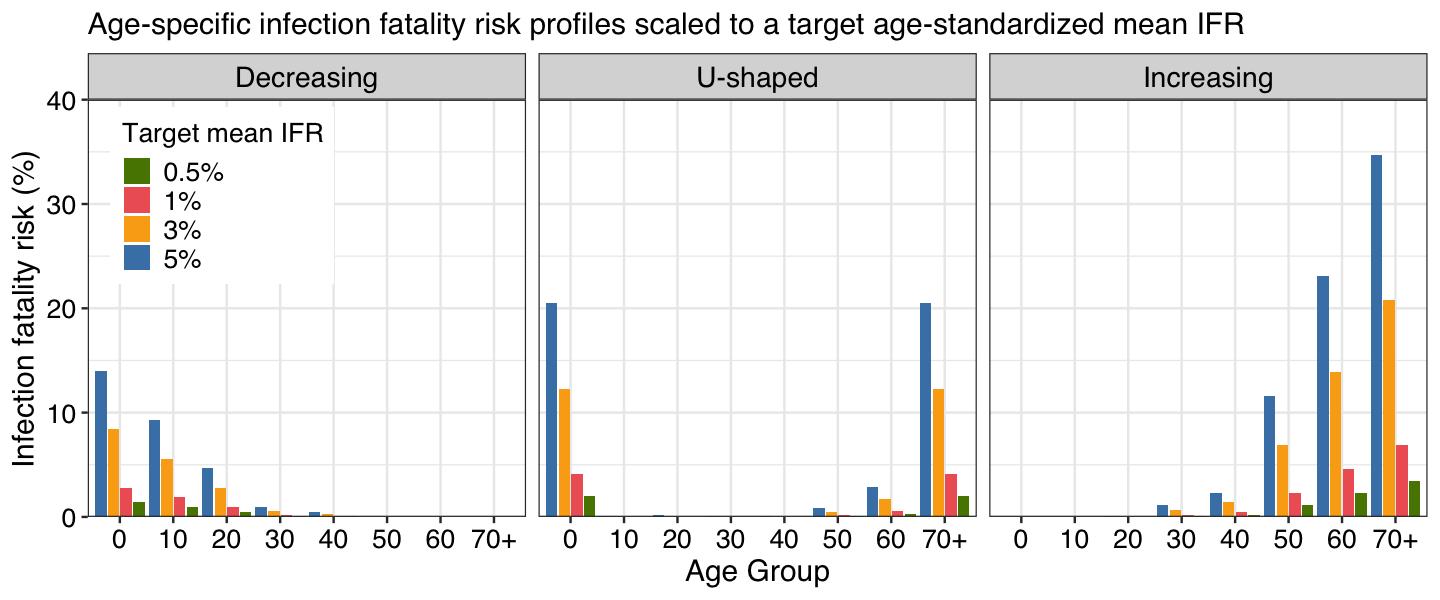

In [9]:
cols_named <- setNames(c("#588300", "indianred2", "#FAAB18", "steelblue"), levels(df_all$k_label))

options(repr.plot.width = 12, repr.plot.height = 5)

ggplot(df_all, aes(x = age_group_fact, y = IFR * 100, fill = k_label_bar)) +
geom_col(width = .95, position = position_dodge2(preserve = "single", width = .95)) +
scale_fill_manual(values = cols_named, breaks = levels(df_all$k_label), labels = levels(df_all$k_label)) +
facet_wrap(~Pattern, nrow = 1) +
labs(x = "Age Group", y = "Infection fatality risk (%)", fill = "Target mean IFR") +
scale_y_continuous(expand = c(0, 0), limits = c(0, 40)) +
ggtitle("Age-specific infection fatality risk profiles scaled to a target age-standardized mean IFR") +
theme_bw(base_size = 15) +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      plot.title = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 16, family = "sans", color = "black"),
      legend.position = "inside", legend.position.inside = c(0.1, 0.77),
      legend.title = element_text(size = 16, color = "black"), legend.text = element_text(size = 16, color = "black"),
      strip.text = element_text(size = 17, family = "sans", color = "black"))

ggsave("figures/WHO_age_profile_IFR_all.png", width = 12, height = 5, dpi = 300, bg = 'white')

## Age group-specific profile of FoI

In [64]:
foi_class <- c("Decreasing FoI", "Constant FoI", "Increasing FoI")

## Decreasing FoI
foi_profile_dec = c(1, .3, .2, .1, .03, .01, .01, .01, .01, .01)

## constant FoI
foi_profile_cons = rep(1, group_num)

## increasing FoI
foi_profile_inc = c(.01, .05, .05, .08, .3, .8, 1, .5, .5, .5)

foi_profile_list <- lapply(target_foi * .01, rep, times = group_num) ## age-constant FoI
foi_profile_list_varying <- list(foi_profile_dec, foi_profile_cons, foi_profile_inc) ## age-varying FoI

## Scaling FoI

In [65]:
target_foi_rates <- target_foi * 0.01
foi_means <- vapply(foi_profile_list_varying, mean, numeric(1))

foi_profile_scale_list <- lapply(seq_along(foi_profile_list_varying), function(g) {
    lapply(seq_along(target_foi_rates), function(k) {foi_profile_list_varying[[g]] * (target_foi_rates[k] / foi_means[g])})})

In [66]:
## plotting age-group–specific FoI profiles with different target mean FoI
k_seq <- seq(target_foi)
k_labels <- paste0(target_foi[k_seq], "%")

bar_order <- c(paste0(target_foi[3], "%"), paste0(target_foi[2], "%"), paste0(target_foi[1], "%"))

list(do.call(rbind, lapply(k_seq, function(k){
        data.frame(AgeGroup = seq_along(foi_profile_scale_list[[1]][[k]]), foi = foi_profile_scale_list[[1]][[k]],
                   Pattern = "Decreasing", k = k, k_label = k_labels[match(k, k_seq)])})),
     
     do.call(rbind, lapply(k_seq, function(k){
         data.frame(AgeGroup = seq_along(foi_profile_scale_list[[2]][[k]]), foi = foi_profile_scale_list[[2]][[k]],
                    Pattern = "Constant", k = k, k_label = k_labels[match(k, k_seq)])})),

     do.call(rbind, lapply(k_seq, function(k){
         data.frame(AgeGroup = seq_along(foi_profile_scale_list[[3]][[k]]), foi = foi_profile_scale_list[[3]][[k]],
                    Pattern = "Increasing", k = k, k_label = k_labels[match(k, k_seq)])}))) -> df_list

df_all <- dplyr::bind_rows(df_list) %>% mutate(AgeGroup = as.numeric(AgeGroup)) %>% filter(AgeGroup <= 8) %>%
mutate(Pattern = factor(Pattern, levels = c("Decreasing", "Constant", "Increasing")),
       age_group_fact = dplyr::if_else(AgeGroup * 10 < 80, as.character((AgeGroup - 1) * 10), "70+"),
       age_group_fact = factor(age_group_fact, levels = c("0", "10", "20", "30", "40", "50", "60", "70+")),
       k_label = factor(k_label, levels = k_labels), k_label_bar = factor(k_label, levels = bar_order))

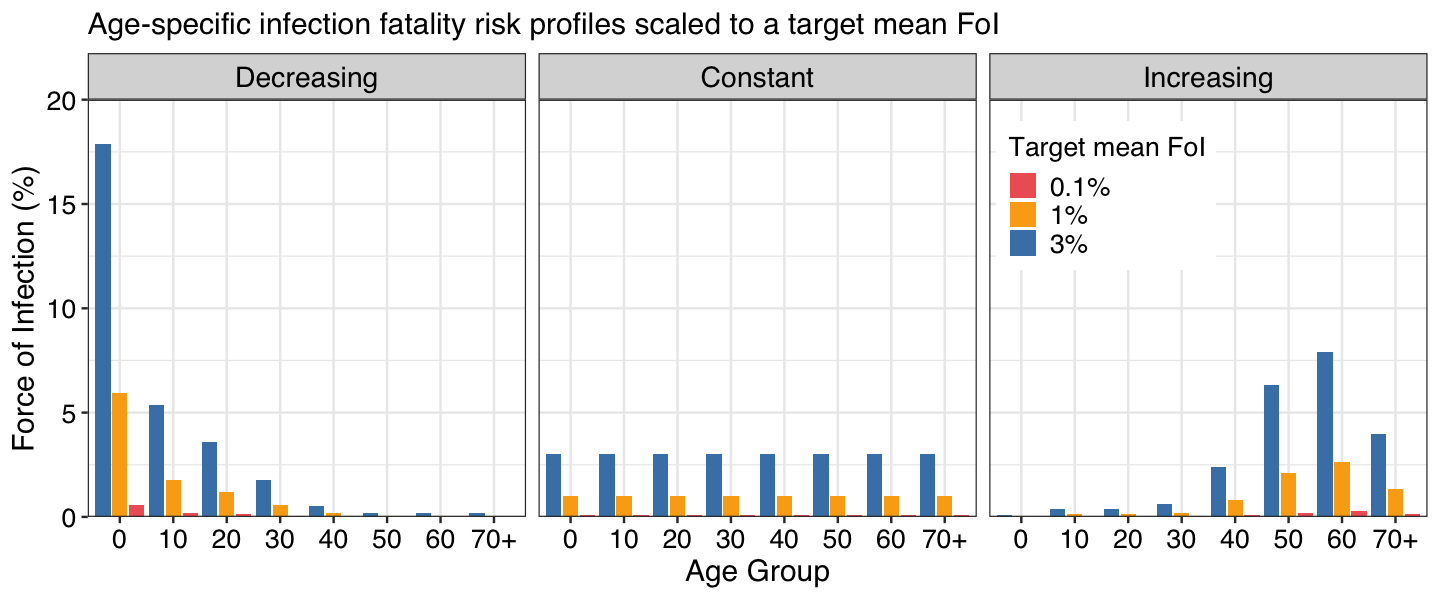

In [69]:
cols_named <- setNames(c("indianred2", "#FAAB18", "steelblue"), levels(df_all$k_label))

options(repr.plot.width = 12, repr.plot.height = 5)

ggplot(df_all, aes(x = age_group_fact, y = foi * 100, fill = k_label_bar)) +
geom_col(width = .95, position = position_dodge2(preserve = "single", width = .95)) +
scale_fill_manual(values = cols_named, breaks = levels(df_all$k_label), labels = levels(df_all$k_label)) +
facet_wrap(~Pattern, nrow = 1) +
labs(x = "Age Group", y = "Force of Infection (%)", fill = "Target mean FoI") +
scale_y_continuous(expand = c(0, 0), limits = c(0, 20)) +
ggtitle("Age-specific infection fatality risk profiles scaled to a target mean FoI") +
theme_bw(base_size = 15) +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      plot.title = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 16, family = "sans", color = "black"),
      legend.position = "inside", legend.position.inside = c(0.76, 0.77),
      legend.title = element_text(size = 16, color = "black"), legend.text = element_text(size = 16, color = "black"),
      strip.text = element_text(size = 17, family = "sans", color = "black"))

ggsave("figures/WHO_age_profile_FoI_all.png", width = 12, height = 5, dpi = 300, bg = 'white')

In [68]:
system("jupyter nbconvert --to script settings_for_simulations.ipynb")